# Surface-code circuit-level swim, complementary gap and path gap v1

Rotated-surface-code **X memory**, using the unmodified PyMatching `SO_example` circuit builder and hard DEM parser. Defaults follow its physical experiment: `p=0.001` and `2d` explicit extraction rounds between noisy X initialization and readout. Initialization also contains an extraction; `rounds` counts the explicit `SE_round` calls.

The small 2,000-shot-per-distance configuration validates the workflow. Rare-error curves can be sparse or absent when no failures occur; zero counts do not establish zero logical error probability. Increase `shots_per_point` deliberately for precision. All three scores use the **same physical shots and ordinary MWPM failure labels**. Complementary gap is `abs(W1-W0)` for the two logical classes in the frozen ordinary graph. Scores are not posterior LLRs; growth is uncertified.

Path gap v1 is `D(E) - W(E)`: zero correction edges in the original split-X-boundary graph, run Dijkstra, then subtract the **entire original correction weight**. Negative values are kept. No growth radii or overlap-only subtraction is used. Old saved runs contain only the original two metrics; set `RUN_NEW_EXPERIMENT=True` explicitly to save all three with the current settings.


In [1]:
from pathlib import Path
import json
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "surface_code_test").is_dir() and (p / "pyproject.toml").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from surface_code_test.simulation import SurfaceConfig
from surface_code_test.experiment import run_experiment, audit_run
from surface_code_test.analysis import (SurfaceDataset, plot_distribution,
                                       plot_conditional_ler, plot_postselection)
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
config = SurfaceConfig(
    distances=(5, 7, 9),
    physical_error_rate=0.003,
    rounds_factor=1,
    shots_per_point=100000,
    batch_size=500,
    num_workers=6,
    master_seed=20260916,
    output_root=ROOT / "surface_code_test/results",
)
verbose = True
RUN_NEW_EXPERIMENT = False
existing_run = "/home/quantum_teresheys/workspace/color_code_softoutput/surface_code_test/results/20260916_211622_177172_surface_code_memory"  # Or Path("/absolute/path/to/a/saved/run")
units = "dB"  # Or "natural". Display conversion only; no integer rounding.
config.resolved()

{'distances': (5, 7, 9),
 'physical_error_rate': 0.003,
 'rounds_factor': 1,
 'shots_per_point': 100000,
 'batch_size': 500,
 'num_workers': 6,
 'master_seed': 20260916,
 'output_root': '/home/quantum_teresheys/workspace/color_code_softoutput/surface_code_test/results'}

In [5]:
if RUN_NEW_EXPERIMENT:
    run_directory = run_experiment(config, analyze=False, verbose=verbose)
elif existing_run is not None:
    run_directory = Path(existing_run)
else:
    candidates = sorted(p.parent for p in config.output_root.glob("*_surface_code_memory/metadata.json")
                        if json.loads(p.read_text())["status"] == "complete")
    if not candidates:
        raise FileNotFoundError("No completed surface run. Set RUN_NEW_EXPERIMENT=True to sample the configured grid.")
    run_directory = candidates[-1]
dataset = SurfaceDataset(run_directory, units=units)
print(run_directory)
print("Loaded settings:", dataset.metadata["resolved_config"])
pd.read_parquet(run_directory / "summary.parquet")

/home/quantum_teresheys/workspace/color_code_softoutput/surface_code_test/results/20260916_211622_177172_surface_code_memory
Loaded settings: {'batch_size': 500, 'distances': [5, 7, 9], 'master_seed': 20260916, 'num_workers': 6, 'output_root': '/home/quantum_teresheys/workspace/color_code_softoutput/surface_code_test/results', 'physical_error_rate': 0.003, 'rounds_factor': 1, 'shots_per_point': 100000}


,distance,rounds,shots,failures
0,5,5,100000,470
1,7,7,100000,218
2,9,9,100000,76


In [6]:
pd.DataFrame(dataset.metadata["static_diagnostics"]).T

,analysis_edges,boundary_labels,detectors,growth_convention,hard_edges,observable_count,swim_bound_certified
5,572,"{'0': [0], '1': [1]}",144,sparse_blossom_final_defect_metric_balls_v1,614,1,False
7,1710,"{'0': [0], '1': [1]}",384,sparse_blossom_final_defect_metric_balls_v1,1798,1,False
9,3800,"{'0': [0], '1': [1]}",800,sparse_blossom_final_defect_metric_balls_v1,3950,1,False


In [ ]:
audit = audit_run(run_directory, replay=False, check_current_sources=False)
audit

## Swim-distance distribution

Successes and failures are marked separately. Costs are saved in natural-log units; dB plots use `10/ln(10)` with no rounding. Distribution and conditional-rate plots use the shared binning/statistical utilities. The post-selection curve below uses every exact unique raw score threshold, with entire ties retained.

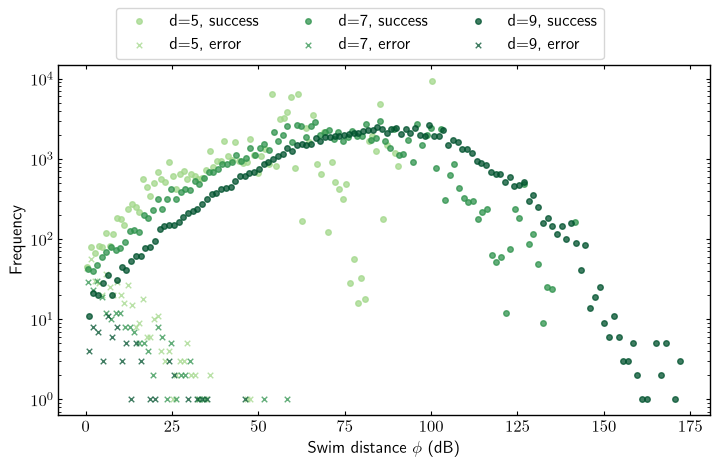

In [7]:
distribution_figure, distribution_counts = plot_distribution(dataset)
display(distribution_figure)
plt.close(distribution_figure)

## Conditional logical error rate

Error bars are the shared 99% Wilson intervals. Zero empirical rates remain in the saved count table but are omitted from the logarithmic plot. No fitted calibration curve is asserted.

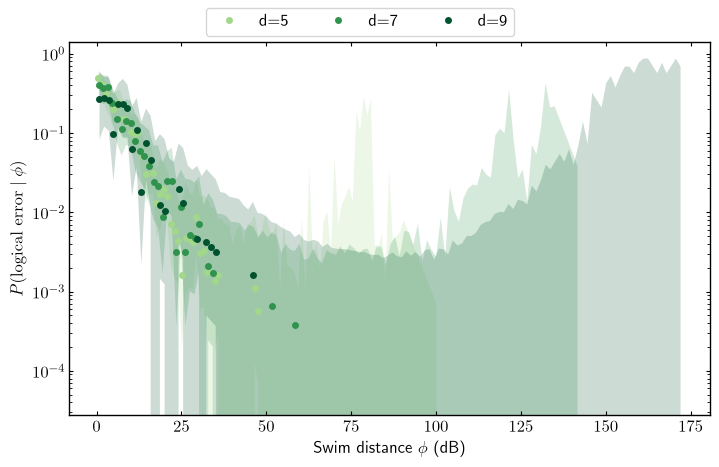

In [8]:
conditional_figure, conditional_counts, fit_diagnostics = plot_conditional_ler(dataset)
display(conditional_figure)
plt.close(conditional_figure)

## Post-selection: swim, complementary gap and path gap v1

Retain scores >= each threshold, keeping whole ties. All metrics use identical ordinary failure labels. Path gap appears automatically for new runs. Legacy runs still plot the original two metrics.


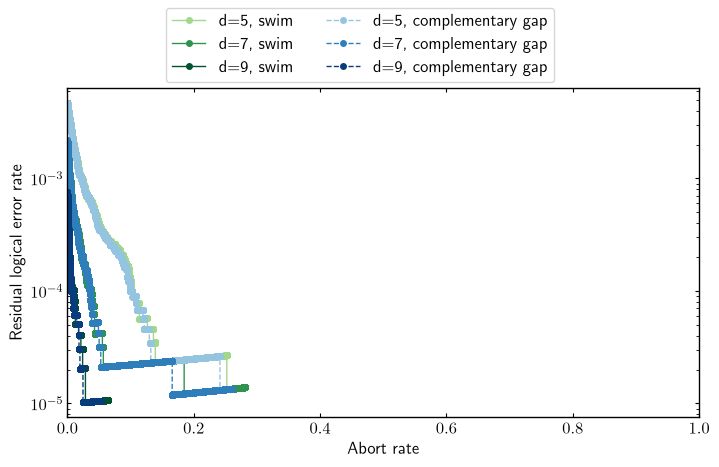

In [12]:
postselection_figure, retention_table = plot_postselection(dataset)
display(postselection_figure)
plt.close(postselection_figure)

In [10]:
rows = dataset.read()
rows.assign(score_difference=(rows.swim_distance - rows.complementary_gap).abs()).nlargest(
    5, "score_difference"
)[["distance", "rounds", "shot_index", "ordinary_logical_error", "swim_distance",
   "complementary_gap", "class_weight_0", "class_weight_1"]]

,distance,rounds,shot_index,ordinary_logical_error,swim_distance,complementary_gap,class_weight_0,class_weight_1
249915,9,9,49915,False,7.152361,19.077804,137.783109,156.860913
233698,9,9,33698,False,8.577684,18.881934,159.973457,141.091523
239868,9,9,39868,False,2.210028,11.494029,139.498407,150.992436
272738,9,9,72738,False,5.568531,14.672208,158.232711,172.904919
266117,9,9,66117,False,10.485449,19.565525,85.604323,105.169848


In [11]:
print("Hard SO-on/off invariance:", dataset.metadata["hard_output_invariance"])
print("Growth certified:", dataset.metadata["swim_bound_certified"])
print("Figures:", run_directory / "figures")
print("Saved units:", dataset.metadata["stored_score_units"])

Hard SO-on/off invariance: {'checked_shots': 300000, 'mismatches': 0}
Growth certified: False
Figures: /home/quantum_teresheys/workspace/color_code_softoutput/surface_code_test/results/20260916_211622_177172_surface_code_memory/figures
Saved units: natural-log matching costs, unrounded


PyMatching now includes `decode_batch_with_path_gap`; the ordinary decoding algorithm and circuit builder are unchanged. This heuristic is not a posterior LLR or a certified gap. SWIM retains its existing uncertified growth convention.


## Path-gap v1 distribution and conditional LER

Signed scores are plotted without clipping. The post-selection figure above compares all three methods on runs containing path gap. The original saved run is preserved.


In [ ]:
if dataset.has_path_gap:
    for plotter in (plot_distribution, plot_conditional_ler):
        outputs = plotter(dataset, metric="path_gap")
        display(outputs[0])
        plt.close(outputs[0])
    display(dataset.read()[["distance", "path_gap", "path_gap_residual_distance",
                            "path_gap_correction_weight", "ordinary_solution_weight"]].groupby("distance").agg(["min", "mean", "max"]))
else:
    print("This saved run has no path gap. Enable RUN_NEW_EXPERIMENT to sample and save all three metrics.")
